# Density Comparison — Papers vs Teams

Kernel-density estimate of each corpus over the shared joint-UMAP space, plotted
as `log2(teams_density / papers_density)`:

- **Red** = teams-dense relative to papers (iGEM activity ahead of the literature)
- **Blue** = papers-dense relative to teams (literature not yet adopted by iGEM)
- **White/neutral** = balanced coverage

This notebook also computes the **temporal precedence** of overlap-zone topics and
saves the tables consumed by `06-deliverables`.

> Run `compute_coords.ipynb` first.

In [1]:
# ── Make the shared aux/ package importable ───────────────────────────────────
# These notebooks live in 05-reporting/ alongside the aux/ package.
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

In [2]:
import matplotlib.pyplot as plt

from aux.paths import REPORTS_DIR, set_seed
from aux.coords import load_plot_data
from aux.density import (
    compute_density_ratio, draw_density_heatmap, topic_zones,
    curated_density_labels, dfprec_extreme_labels,
)
from aux.labels import add_density_labels
from aux.precedence import compute_precedence, save_precedence

set_seed()
df_papers, df_teams, XLIM, YLIM = load_plot_data()
papers_xy = df_papers[["x", "y"]].to_numpy()
teams_xy = df_teams[["x", "y"]].to_numpy()
print(f"Papers: {len(df_papers):,} | Teams: {len(df_teams):,}")

Papers: 19,017 | Teams: 4,707


## 1. Density-ratio grid

In [3]:
dens = compute_density_ratio(papers_xy, teams_xy, XLIM, YLIM, grid_res=300, bw=0.15)
print(f"Grid {dens['grid_res']}x{dens['grid_res']}, ratio clipped to ±{dens['vmax']:.2f}")

Grid 300x300, ratio clipped to ±19.01


## 2. Density-ratio heatmap (curated labels)

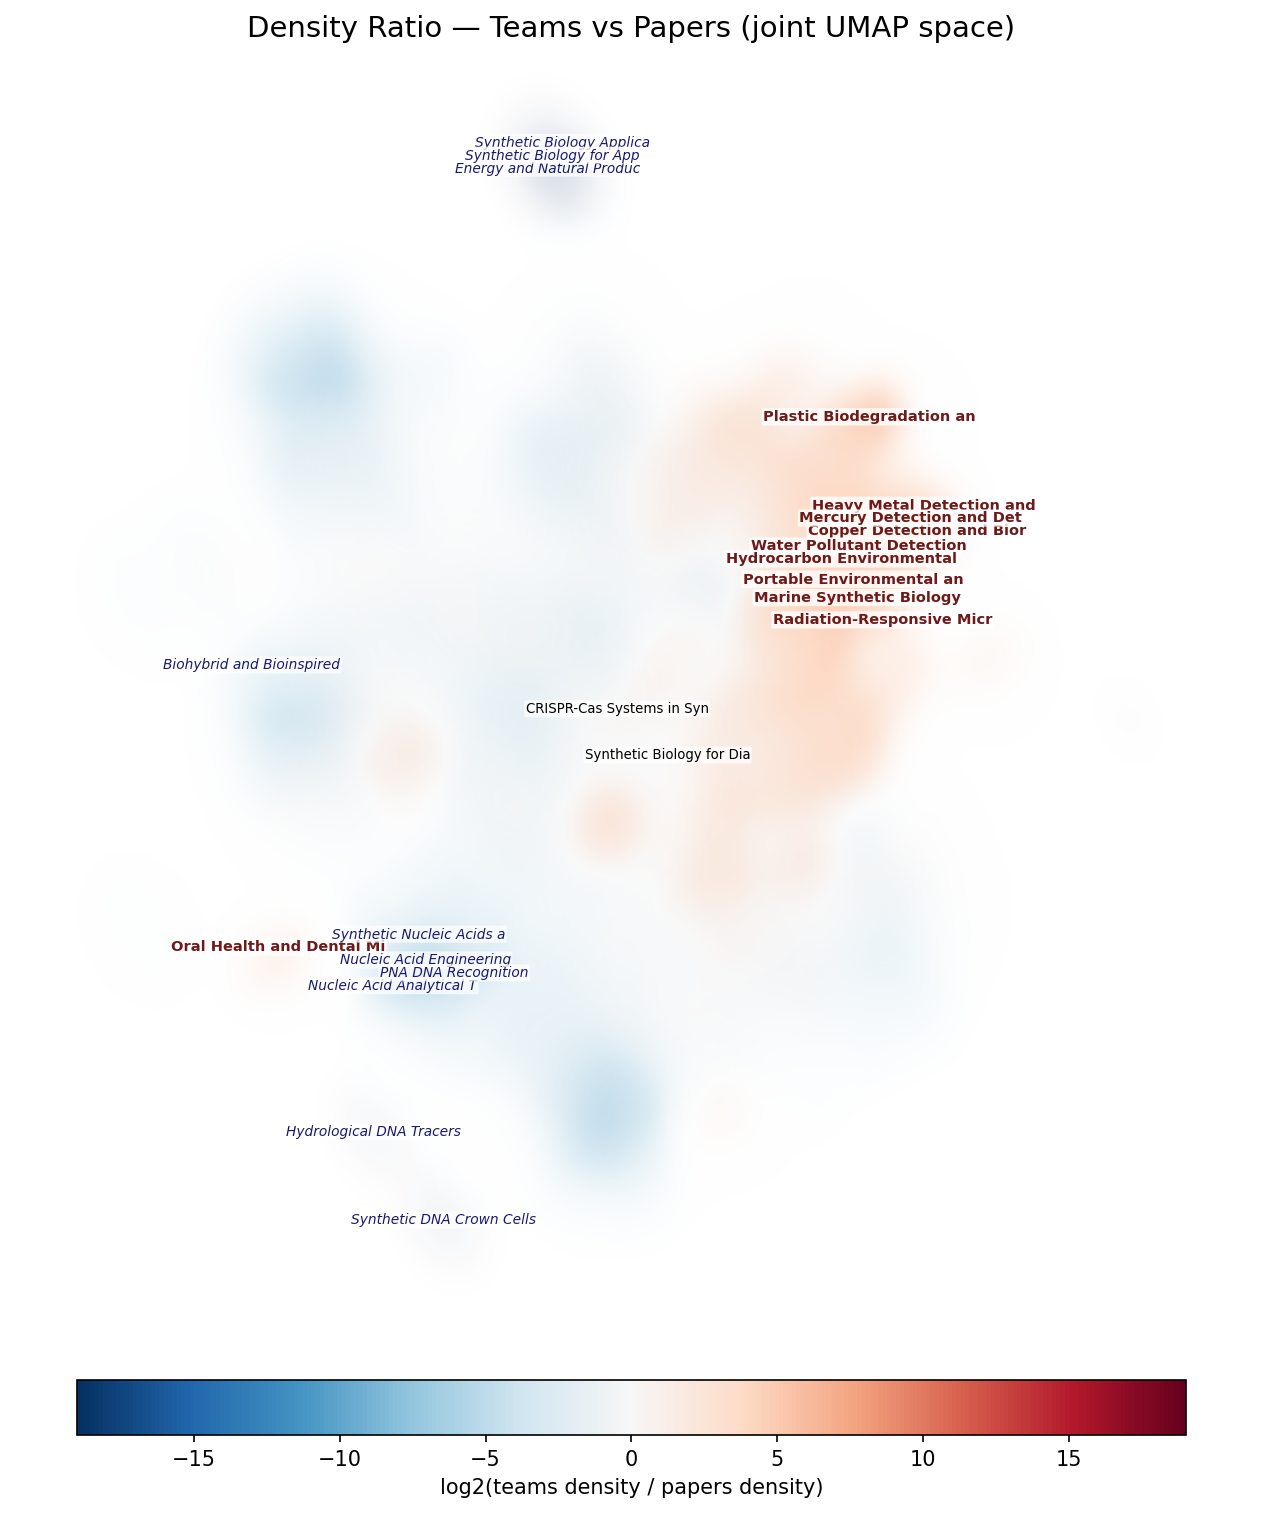

In [4]:
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
draw_density_heatmap(ax, dens, XLIM, YLIM)

papers_ctr = topic_zones(df_papers, "topic", "low_name", dens["ratio_interp"])
teams_ctr = topic_zones(df_teams, "topic", "low_name", dens["ratio_interp"])
add_density_labels(ax, curated_density_labels(papers_ctr, teams_ctr, n=10), XLIM, YLIM)

ax.set_title("Density Ratio — Teams vs Papers (joint UMAP space)", fontsize=14)
fig.savefig(REPORTS_DIR / "umap_density_ratio.png", dpi=220, bbox_inches="tight")
plt.show()

## 3. Temporal precedence of overlap topics

For each overlap-zone paper topic, find the teams nearby in the joint space and
compare year distributions. `delta_*_years < 0` → iGEM teams preceded the
literature; `> 0` → the literature preceded iGEM.

In [5]:
df_prec, papers_ctr, teams_ctr = compute_precedence(df_papers, df_teams, dens["ratio_interp"])
igem, lit = save_precedence(df_prec)

print("Papers topics by zone:", papers_ctr["zone"].value_counts().to_dict())
print(f"Overlap topics: {len(df_prec)} | iGEM-first: {len(igem)} | literature-first: {len(lit)}")
print(f"Saved → {REPORTS_DIR}: overlap_precedence_full.tsv, igem_preceded.tsv, literature_preceded.tsv")
df_prec.head(10)

Papers topics by zone: {'papers-only': 122, 'overlap': 70, 'teams-dominant': 33}
Overlap topics: 64 | iGEM-first: 37 | literature-first: 27
Saved → /Users/cristian/Desktop/GitHub/igem-synbio/assets/reports: overlap_precedence_full.tsv, igem_preceded.tsv, literature_preceded.tsv


,topic,global_name,n_papers,n_nearby_teams,papers_min_year,papers_q1_year,papers_mean_year,papers_median_year,papers_q3_year,papers_max_year,...,teams_mean_year,teams_median_year,teams_q3_year,teams_max_year,delta_min_years,delta_q1_years,delta_mean_years,delta_median_years,delta_q3_years,delta_max_years
0,86,Peptide Biosynthesis and Engineering,49,6,2010.0,2018.00,2020.47,2021.0,2024.00,2025.0,...,2013.83,2013.5,2015.5,2017.0,1.0,-5.75,-6.64,-7.5,-8.50,-8.0
1,127,Genetic Logic and Memory Devices,36,32,2008.0,2014.00,2017.86,2018.5,2022.00,2025.0,...,2011.66,2012.0,2014.0,2025.0,-3.0,-6.00,-6.20,-6.5,-8.00,0.0
2,163,Biological Computation and Logic,27,5,2009.0,2014.00,2016.07,2016.0,2019.00,2025.0,...,2011.00,2011.0,2014.0,2018.0,-4.0,-7.00,-5.07,-5.0,-5.00,-7.0
3,155,Synthetic Signal Transduction,30,18,2006.0,2012.00,2015.23,2014.0,2019.75,2025.0,...,2011.00,2011.0,2013.0,2019.0,0.0,-4.00,-4.23,-3.0,-6.75,-6.0
4,113,Microbial Community Design,39,3,2007.0,2013.50,2017.67,2018.0,2022.00,2025.0,...,2013.67,2012.0,2015.0,2018.0,4.0,-2.00,-4.00,-6.0,-7.00,-7.0
5,110,Magnetic Bioengineering,40,20,2011.0,2018.00,2020.25,2021.0,2023.25,2025.0,...,2016.35,2015.0,2020.0,2025.0,0.0,-4.25,-3.90,-6.0,-3.25,0.0
6,203,Essential Gene Prediction,22,4,2008.0,2011.25,2015.68,2015.0,2018.75,2025.0,...,2012.00,2011.5,2013.5,2015.0,2.0,-1.25,-3.68,-3.5,-5.25,-10.0
7,30,Genetic Engineering Tools for Eukaryotes,95,88,2004.0,2014.00,2017.61,2018.0,2022.00,2025.0,...,2014.50,2013.5,2018.0,2025.0,1.0,-3.00,-3.11,-4.5,-4.00,0.0
8,55,Living and Hybrid Material Systems,71,19,2005.0,2017.00,2019.73,2021.0,2024.00,2025.0,...,2016.68,2016.0,2019.5,2025.0,5.0,-2.50,-3.05,-5.0,-4.50,0.0
9,32,Yeast Synthetic Biology,93,33,2008.0,2017.00,2019.68,2020.0,2023.00,2025.0,...,2016.70,2018.0,2020.0,2025.0,0.0,-4.00,-2.98,-2.0,-3.00,0.0


## 4. Density-ratio heatmap (precedence extremes)

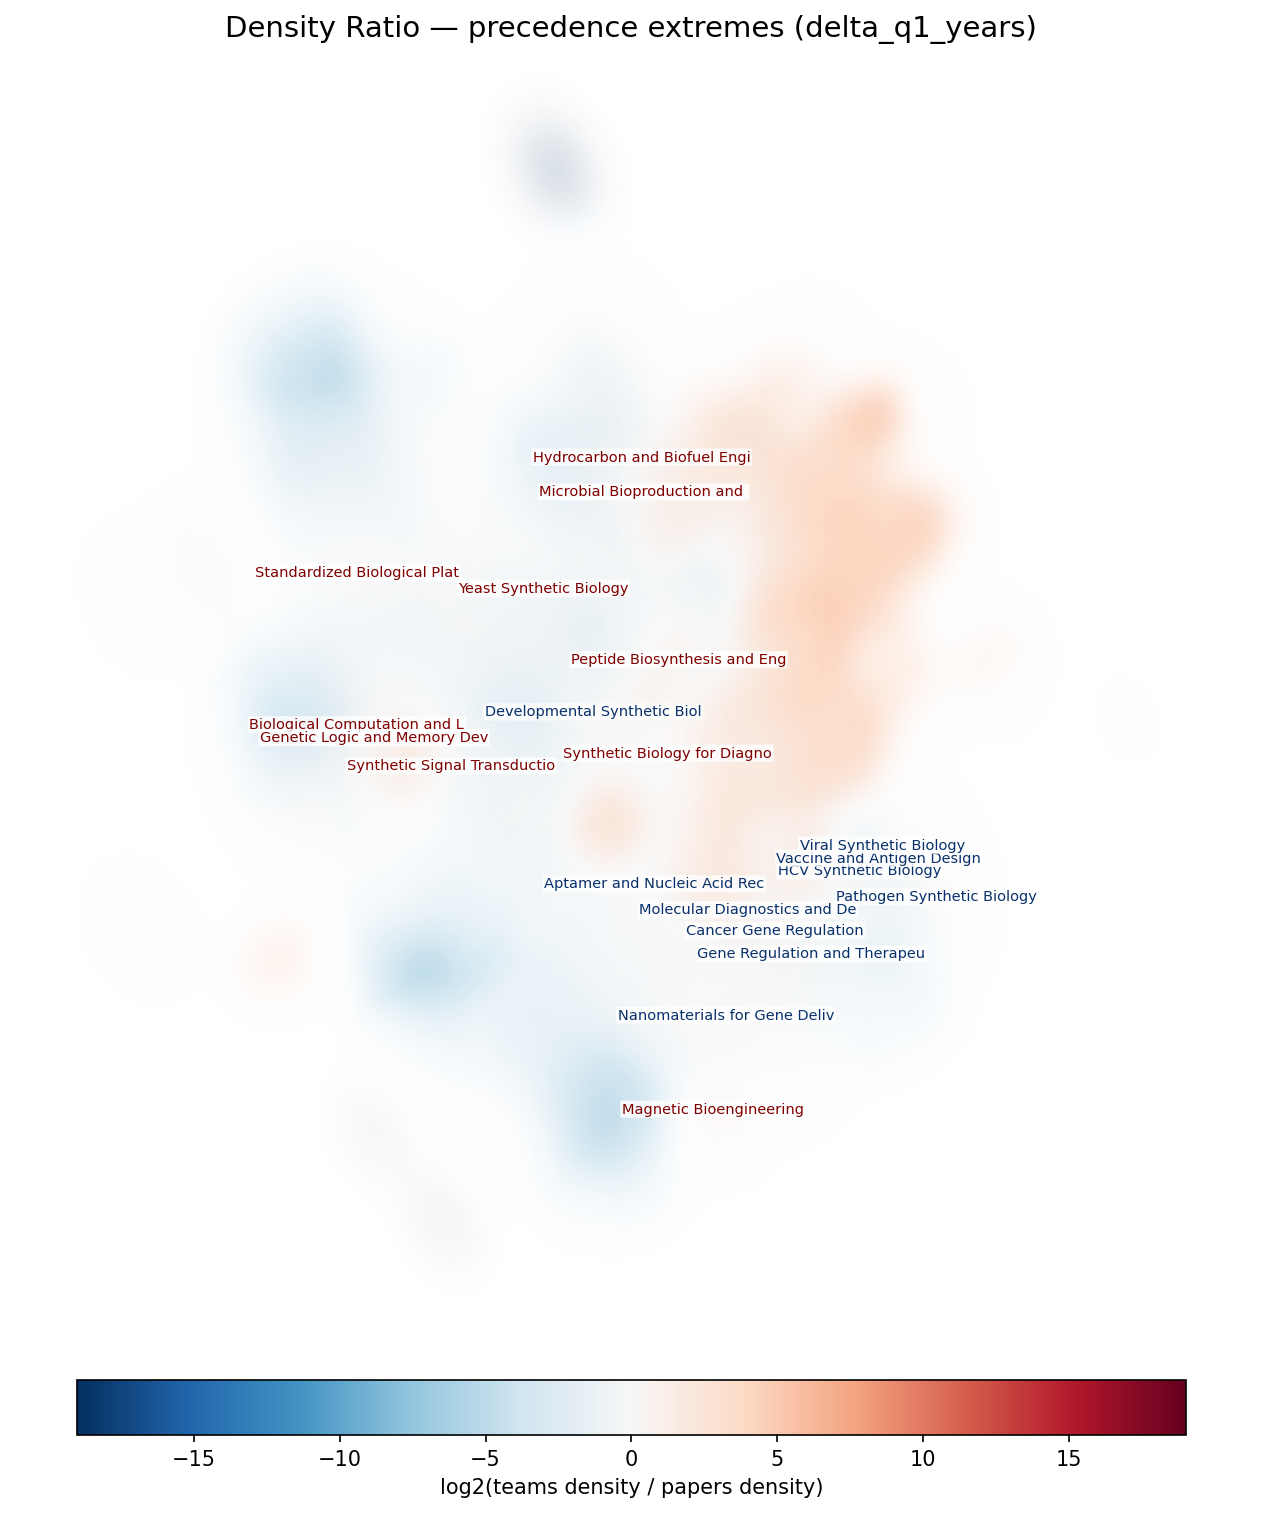

In [6]:
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
draw_density_heatmap(ax, dens, XLIM, YLIM)
add_density_labels(ax, dfprec_extreme_labels(df_prec, papers_ctr, n_extreme=10), XLIM, YLIM)

ax.set_title("Density Ratio — precedence extremes (delta_q1_years)", fontsize=14)
fig.savefig(REPORTS_DIR / "umap_density_ratio_extremes.png", dpi=220, bbox_inches="tight")
plt.show()